# [PBT] 화장품 이커머스 ㅣ 09. 단변량 분석 — A조 · 탐색 행동 4종

## 이 노트북이 하는 일

마스터 테이블(108,458행)의 **탐색 행동 변수 4종** 을 하나씩 들여다본다.

교재가 단변량 단계에 부여한 질문은 **딱 하나**다 — `[LAB-08 4단원 p.3]`

> **"이 변수를 그대로 검정에 넣어도 되는가?"** (채택 근거 4요소 중 **④ 데이터 적격성**)

`[LAB-08 2단원 p.2]`가 이어서 말한다 — 치우침이 강하면 → 로그변환 / 이상치가 많으면 → 처리 고려 /
불균형 명목형이면 → 비교 및 해석 신중.

## ⚠️ 이 노트북에서 **Y를 보지 않는다**

`purchase_7d`와의 관계는 **이변량(10번)**의 일이다. 단변량에서 Y를 들여다보면
"이 변수 세네 → 기준을 이렇게 잡자"가 되어 §12 규율(기준은 결과를 보기 전에 확정)이 깨진다.

**유일한 예외** — `#01-4`의 08번 대조 셀. 거기서 확인하는 Y 양성 22,236명·20.50%는
이미 브리핑에 적혀 있는 **알려진 값**이라 새 정보가 아니다. 파일이 맞는지 보는 용도다.

## 여기서 하지 않는 것

| 안 하는 것 | 어디서 하는가 |
|---|---|
| 로그변환·이상치 **처리** | ⑤ 모델링용 전처리. **여기서는 판정만** |
| Y와의 관계(이변량) | `10` |
| 다변량·VIF·변수 선택 | `10` |
| 단조성·구간별 Y 비율 | **하지 않는다.** 로짓 선형성은 ⑤의 Box-Tidwell로 (설계 §3-10) |
| 더미 인코딩 | 모델링 단계 — **분할 후** (LAB-13 04) |

## 번호 체계

| 체계 | 이 노트북에서 |
|---|---|
| 파일명 | `09` |
| 프로세스 단계 | **④ 탐색적 데이터 분석 — STEP 2 단변량** |
| 결과 보고서 장 | **Ⅱ-1 단변량** |

---

---

## 🔧 수정 내역 (2026-08-31, Claude)

> **⚠️ 이 파일은 열자마자 「Run All」로 전체 재실행해야 한다.**
> 판정문이 **새로 추가된 셀의 출력**을 인용하므로, 재실행 전에는 근거를 되짚을 수 없다.

| # | 무엇을 | 왜 |
|---|---|---|
| **1** | `#01`에 `from numpy import log1p` 추가 | 아래 2번이 쓴다 |
| **2** | **`#04-1-1` 신설** — 로그변환 전후 왜도·고유값 비교 | **설계 §3-4가 요구한 확인이 빠져 있었다.** `#04-1` 설명글은 *"따로 확인해야 한다"*고 적어놓고 셀이 없었다 (노트북을 만든 Claude의 누락) |
| **3** | **`#04-2-1` 신설** — 전 구간 단조성 | 판정문의 *"계속 줄어든다"*가 **상위 5개까지만** 근거였다 |
| **4** | `#07` 판정표 — 봉우리 서술 정정 · 상관 0.969 **출처 표기** · **판단·조치 재작성** | 근거 추적성. 그리고 `로그 변환` 과 `사실상 범주형` 두 조치가 **방향이 반대**라 ⑤에서 무엇을 할지 정해지지 않았다 |
| **5** | `#08` 요약표 — `판단·조치`를 `dict`로 배선 | 넘겨진 CSV의 해당 칸이 **전부 공란**이었다. 이제 키가 빠지면 `KeyError`로 즉시 터진다 |

**건드리지 않은 것** — `#07` 판정표의 **관찰 내용 칸**(이슬기 작성)은 봉우리 행을 뺀 나머지를 그대로 두었다.
수치 정합성을 전수 대조했고 셀 출력과 **전부 일치**했다.

---

## #01. 준비작업

### 1. 라이브러리 참조

`helpers`는 학원 교재(LAB-05·07·08)에서 만든 모듈이다. 우리가 새로 만들지 않는다.

In [1]:
import os, sys

# ── helpers 폴더가 들어 있는 작업 폴더 ──────────────────────────────
# my_plot 의 한글 폰트 경로가 '상대경로'로 적혀 있어서,
# 반드시 이 폴더로 chdir 한 뒤에 helpers 를 import 해야 글자가 깨지지 않는다.
# 프로젝트 폴더 — notebooks/ 안에서 실행하면 상위 폴더를 가리킨다
from pathlib import Path
BASE = str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())

os.chdir(BASE)              # 폰트 경로 때문에 먼저 이동
sys.path.insert(0, BASE)    # helpers 를 import 할 수 있게 경로 추가

from numpy import log1p
from pandas import read_csv, to_datetime, DataFrame, set_option
from helpers import my_qtcheck, my_plot

# 컬럼이 많아 잘리는 것을 막는다 (마스터는 16열)
set_option("display.max_columns", 50)

print("작업 폴더 :", os.getcwd())

작업 폴더 : .


### 2. 경로 지정

**BASE 한 줄만 각자 PC에 맞게 바꾼다.** 나머지 코드는 두 사람이 동일하다.

In [2]:
# ── 데이터가 들어 있는 프로젝트 폴더 ────────────────────────────────

OUT = BASE + r"\output"         # 산출물 폴더

print("데이터 폴더 :", OUT)

데이터 폴더 : .\output


### 3. 마스터 테이블 불러오기

**CSV는 타입을 보존하지 않는다.** 저장할 때 전부 문자열이 되므로 08번에서 정한 타입을 되살려야 한다.

- `cart_timeband`·`cart_weekday`는 **순서가 있는** 범주다.
  `set_categories(..., ordered=True)`로 순서를 지정하지 않으면 표와 그래프가 가나다순으로 뒤섞인다.
- `lag_hours`는 불러오기는 하되 **어떤 분석에도 쓰지 않는다.** 누수 변수다(브리핑 §4).
- `utf-8-sig`로 저장했으므로 같은 인코딩으로 읽는다 (엑셀에서 한글이 깨지지 않게 한 조치).

In [3]:
m = read_csv(OUT + r"\03_master.csv", encoding="utf-8-sig")

# ── 타입 복원 ────────────────────────────────────────────────────
m["t0"]          = to_datetime(m["t0"], format="%Y-%m-%d %H:%M:%S")
m["product_id"]  = m["product_id"].astype("int32")
m["purchase_7d"] = m["purchase_7d"].astype("int8")

# 순서 있는 범주 — 순서를 명시해야 표·그래프가 시간 순서대로 나온다
m["cart_timeband"] = m["cart_timeband"].astype("category").cat.set_categories(
    ["심야", "오전", "오후", "저녁"], ordered=True)
m["cart_weekday"]  = m["cart_weekday"].astype("category").cat.set_categories(
    ["월", "화", "수", "목", "금", "토", "일"], ordered=True)

# 순서 없는 범주
for c in ["brand_grp", "category_grp"]:
    m[c] = m[c].astype("category")

print(f"{len(m):,}행 × {m.shape[1]}열")

108,458행 × 16열


### 4. 08번 값과 대조 — **하나라도 어긋나면 여기서 멈춘다**

파일을 잘못 읽었는데 그대로 진행하면 이후 전부가 무의미해진다.
아래 값은 전부 브리핑 §2·§3에 이미 기록된 **알려진 값**이므로, 확인해도 새 정보를 얻는 것이 아니다.

In [4]:
ok = []

ok.append(("행 수",        f"{len(m):,}",                          "108,458"))
ok.append(("1행 = 1고객",  str(len(m) == m["user_id"].nunique()),  "True"))
ok.append(("Y 양성",       f"{int(m['purchase_7d'].sum()):,}명 / {m['purchase_7d'].mean():.2%}",
                                                                   "22,236명 / 20.50%"))
ok.append(("brand_grp",    f"{m['brand_grp'].nunique()}종",        "15종"))
ok.append(("category_grp", f"{m['category_grp'].nunique()}종",     "59종"))
ok.append(("t0 최소",      str(m["t0"].min()),                     "2019-10-11 00:00:17"))
ok.append(("t0 최대",      str(m["t0"].max()),                     "2019-11-24 02:58:43"))

chk = DataFrame(ok, columns=["항목", "이번 실행", "08번 값"])
chk["일치"] = chk["이번 실행"] == chk["08번 값"]
chk

,항목,이번 실행,08번 값,일치
0,행 수,"108,458","108,458",True
1,1행 = 1고객,True,True,True
2,Y 양성,"22,236명 / 20.50%","22,236명 / 20.50%",True
3,brand_grp,15종,15종,True
4,category_grp,59종,59종,True
5,t0 최소,2019-10-11 00:00:17,2019-10-11 00:00:17,True
6,t0 최대,2019-11-24 02:58:43,2019-11-24 02:58:43,True


> 위 표의 `일치` 칸이 **전부 True**여야 다음으로 넘어간다.
> 하나라도 False면 `OUT` 경로나 `03_master.csv` 파일 자체를 다시 확인한다.

---

## #02. 설계에서 가져온 판정 기준

전문은 `claude/09_EDA_설계.md`. **실행하면서 계속 봐야 하는 것만** 옮긴다.
**결과를 본 뒤에 이 기준을 바꾸지 않는다.**

### 연속형 — 점검 항목 4개 

| 항목 | 무엇을 보나 |
|---|---|
| **분포 모양(왜도)** | 정규 / 치우침 |
| **봉우리 수** | 단봉 / 다봉 |
| **이상치** | 박스플롯의 점. IQR 밖 개수와 비율 |
| **이산점(군집)** | 값이 특정 지점에 뭉치는가 |

### 명목형 — 균형 점검 

`범주 수 | 최빈 범주(비율) | 최소 범주(비율) | 균형 여부 | 판단·조치`

### 확정된 판정 기준

| 항목 | 우리 기준 | 근거 |
|---|---|---|
| 로그변환 대상 | **`\|왜도\| >= 1.0`** — **판정만**, 실행은 ⑤ | 「**교재 미기재**」. 교재에 로그변환 기준이 없다. 다만 우리 값이 1.75~7.21이라 1을 쓰든 2를 쓰든 결과가 같다 |
| 이상치 | **IQR 1.5배로 개수만 세고 처리하지 않는다** | `[LAB-07 10단원 p.4]`가 IQR 규칙을 준다. **처리 방법은 교재가 다루지 않으므로** 처리하지 않는 쪽이 보수적 |
| 명목형 소수 범주 | **하한을 두지 않는다.** 유지하되 서술에서 "판정 불가" | `[LAB-08 §3-4]` CHAS 선례 — *"검정력 낮음 → 신중히 해석. 버리지 않고 유지"* |

> ⚠️ **`numerical_summary`의 `skew_interpret` 라벨을 그대로 쓰지 말 것.**
> 그 함수는 `±0.5`를 기준으로 `right tail`/`symmetric`을 붙이는데, 이는 **분포 모양을 부르는 이름**일 뿐
> **로그변환 판정 기준이 아니다.** 우리 기준은 위 표의 `1.0`이다. 두 숫자를 섞지 않는다.

---

## #03. 대상 변수 확인

```
연속형 3 : prior_view_cnt · prior_uniq_product_cnt · cart_product_view_cnt
이진   1 : has_prior_view
```

**이 4개를 한 사람이 통째로 본다.** 서로 얽혀 있어서 따로 보면 판단이 안 되기 때문이다.

- `has_prior_view`는 `prior_view_cnt`를 0 / 1이상으로 뭉갠 것이라 **완전 종속**이다 (`cnt > 0 ⟺ yn = 1`)
- `prior_view_cnt`와 `prior_uniq_product_cnt`는 상관 **0.969**, 두 값 일치 비율 **90.0%**

> **셋 중 무엇을 남길지는 여기서 정하지 않는다.** 10번 다변량(VIF)의 일이다.
> 지금은 각각이 "투입 가능한 상태인가"만 본다.

### 변수의 뜻 (브리핑 §4)

| 변수 | 의미 |
|---|---|
| `prior_view_cnt` | t₀ 직전 **30분** 조회 **건수** |
| `prior_uniq_product_cnt` | 그 구간에 조회한 상품 **종류** 수 |
| `cart_product_view_cnt` | 그 구간에서 **담은 그 상품을** 조회한 횟수 |
| `has_prior_view` | 조회 여부 0/1 |

In [5]:
A_NUM = ["prior_view_cnt", "prior_uniq_product_cnt", "cart_product_view_cnt"]
A_BIN = "has_prior_view"

# 결측이 없어야 정상이다 (04번에서 조회가 없으면 0으로 채웠으므로)
print(m[A_NUM + [A_BIN]].isna().sum())

prior_view_cnt            0
prior_uniq_product_cnt    0
cart_product_view_cnt     0
has_prior_view            0
dtype: int64


## #04. 연속형 3종 — 기술통계

`my_qtcheck.numerical_summary`는 교재(LAB-05)가 만든 함수다. 한 번 호출로 아래를 전부 준다.

| 컬럼 | 뜻 |
|---|---|
| `count`~`max` | `describe()` 기본 통계 |
| `rel_diff` / `rdiff_flag` | 평균과 중앙값의 상대 차이 — 치우침의 간접 신호 |
| `iqr` / `upper_bound` / `lower_bound` | **IQR 1.5배** 이상치 경계 |
| `upper_outliers` / `lower_outliers` / `outliers` | 경계 밖 **개수** |
| `outliers_ratio` | 그 비율 |
| `skew` / `skew_interpret` | **왜도**와 그 라벨(±0.5 기준) |
| `kurt` / `kurt_interpret` | 첨도와 그 라벨 |

**우리가 손으로 계산할 것이 없다.** 읽고 해석만 한다.

In [6]:
A_SUM = my_qtcheck.numerical_summary(m, columns=A_NUM)
A_SUM.round(3).T

,prior_view_cnt,prior_uniq_product_cnt,cart_product_view_cnt
count,108458.0,108458.0,108458.0
mean,1.28,1.12,0.458
std,2.345,1.988,0.658
min,0.0,0.0,0.0
25%,0.0,0.0,0.0
50%,1.0,1.0,0.0
75%,1.0,1.0,1.0
max,71.0,71.0,10.0
rel_diff,0.28,0.12,inf
rdiff_flag,diff,diff,large_diff


### 4-1. 판정에 필요한 칸만 추린다

위 표는 컬럼이 많아 한눈에 안 들어온다. **점검 항목 4개**에 대응하는 값만 뽑는다.

`0의 비율`은 함수가 주지 않으므로 직접 센다. 조회 변수는 0이 많을 것으로 예상되고,
**0이 많으면 로그변환(log1p)이 실제로 분포를 개선하는지 따로 확인해야 하기 때문**이다.

In [7]:
view = A_SUM[["mean", "50%", "max", "skew", "outliers", "outliers_ratio"]].copy()

view["0의 비율%"] = [round((m[c] == 0).mean() * 100, 2) for c in A_NUM]
view["고유값 수"]  = [m[c].nunique() for c in A_NUM]

# 설계에서 확정한 기준 : |왜도| >= 1.0 이면 로그변환 '후보'  (판정만, 실행은 ⑤)
view["로그변환 후보"] = view["skew"].abs() >= 1.0

view["outliers_ratio"] = (view["outliers_ratio"] * 100).round(2)
view.rename(columns={"outliers_ratio": "이상치%"}, inplace=True)

view.round(3).T

,prior_view_cnt,prior_uniq_product_cnt,cart_product_view_cnt
mean,1.28,1.12,0.458
50%,1.0,1.0,0.0
max,71.0,71.0,10.0
skew,5.901,6.044,1.751
outliers,14961,11947,1234
이상치%,13.79,11.02,1.14
0의 비율%,44.68,44.68,61.3
고유값 수,51,46,10
로그변환 후보,True,True,True


### 4-1-1. 로그변환이 실제로 효과가 있는가 〈추가된 셀〉

설계 §3-4가 요구한 확인이다 — **"변환 전후 왜도를 비교한다. 개선되지 않으면 변환하지 않는다."**

0이 44~61%라 `log`는 쓸 수 없다(`log(0)`이 정의되지 않는다). **`log1p`로 확인한다.**

> **판정만 한다.** 실제 변환은 ⑤ 모델링용 전처리에서, **층화 분할 후**에 한다.

In [8]:
# 변환 전후 왜도와, 값의 '종류'가 줄어드는지를 함께 본다.
log_chk = DataFrame({
    "변환 전 왜도":   [round(m[c].skew(), 3)         for c in A_NUM],
    "log1p 후 왜도":  [round(log1p(m[c]).skew(), 3)  for c in A_NUM],
    "고유값 (원)":    [m[c].nunique()                for c in A_NUM],
    "고유값 (log1p)": [log1p(m[c]).nunique()         for c in A_NUM],
}, index=A_NUM)

# 우리 기준은 1.0 (설계 §3-4). 변환 '후'에도 기준을 넘는지 본다.
log_chk["기준 1.0 통과"] = log_chk["log1p 후 왜도"].abs() < 1.0

log_chk

,변환 전 왜도,log1p 후 왜도,고유값 (원),고유값 (log1p),기준 1.0 통과
prior_view_cnt,5.901,1.042,51,51,False
prior_uniq_product_cnt,6.044,1.033,46,46,False
cart_product_view_cnt,1.751,0.809,10,10,True


> **읽는 법 두 가지**
>
> 1. **개선 폭**과 **기준 통과 여부**는 다른 질문이다. 크게 좋아졌어도 기준(1.0)을 못 넘을 수 있다.
> 2. `log1p`는 **단조변환**이라 값의 '종류'가 줄지 않는다. 즉 **왜도는 잡아도 이산성은 그대로 남는다.**
>    이 둘을 같은 조치로 묶지 않는다.

> **이상치를 처리하지 않는다**(설계 §3-5). 개수를 세는 것은 "얼마나 있는지 기록"하기 위해서다.
> 조회 건수의 큰 값은 오류가 아니라 **실제로 많이 본 고객**이다.

### 4-2. 봉우리 수와 이산점(군집)의 근거

점검 항목 ②(봉우리 수)와 ④(이산점)는 요약 통계로는 안 보인다. **값의 분포를 직접 세어야** 한다.

이 변수들은 **정수 카운트**라 값 종류가 적다. 상위 몇 개 값이 전체의 몇 %를 덮는지 보면
"특정 지점에 뭉쳐 있는가"가 바로 드러난다.

In [9]:
for c in A_NUM:
    vc = m[c].value_counts().sort_index()
    top = vc.sort_values(ascending=False).head(5)

    print("=" * 60)
    print(f"{c}   (고유값 {m[c].nunique()}종, 최대 {m[c].max()})")
    print(f"  상위 5개 값이 덮는 비율 : {top.sum() / len(m) * 100:.2f}%")
    print()
    print("  값별 빈도 (상위 5)")
    for v, n in top.items():
        print(f"    {v:>3} : {n:>7,}명 ({n/len(m)*100:5.2f}%)")
    print()

prior_view_cnt   (고유값 51종, 최대 71)
  상위 5개 값이 덮는 비율 : 94.06%

  값별 빈도 (상위 5)
      0 :  48,457명 (44.68%)
      1 :  33,259명 (30.67%)
      2 :  11,781명 (10.86%)
      3 :   5,520명 ( 5.09%)
      4 :   2,999명 ( 2.77%)

prior_uniq_product_cnt   (고유값 46종, 최대 71)
  상위 5개 값이 덮는 비율 : 95.60%

  값별 빈도 (상위 5)
      0 :  48,457명 (44.68%)
      1 :  36,889명 (34.01%)
      2 :  11,165명 (10.29%)
      3 :   4,652명 ( 4.29%)
      4 :   2,528명 ( 2.33%)

cart_product_view_cnt   (고유값 10종, 최대 10)
  상위 5개 값이 덮는 비율 : 99.92%

  값별 빈도 (상위 5)
      0 :  66,490명 (61.30%)
      1 :  35,897명 (33.10%)
      2 :   4,837명 ( 4.46%)
      3 :     923명 ( 0.85%)
      4 :     227명 ( 0.21%)



### 4-2-1. 전 구간에서도 단조인가 〈추가된 셀〉

위 셀은 **상위 5개 값**만 보여준다. 판정문에 *"값이 커질수록 계속 줄어든다"*고 쓰려면
꼬리까지 포함한 **전 구간**을 확인해야 한다.

> 역전이 있더라도 **규모가 작으면 꼬리의 노이즈**다. 개수와 최대 폭을 함께 보고 판단한다.

In [10]:
# ── 전 구간 단조성 ─────────────────────────────────────────────────
# 판정문에 "값이 커질수록 계속 줄어든다"고 쓰려면
# 상위 5개가 아니라 '전 구간'을 봐야 한다.
for c in A_NUM:
    vc = m[c].value_counts().sort_index()   # 값 오름차순으로 정렬
    d   = vc.diff().dropna()                # 이웃한 값 사이의 빈도 변화량
    rev = d[d > 0]                          # 0 보다 크면 '늘어난' 것 = 역전

    print(f"{c}")
    print(f"  전 구간 단조감소 : {bool((d <= 0).all())}")
    print(f"  역전 {len(rev)}회"
          + (f" / 최대 +{int(rev.max())}명" if len(rev) else ""))
    print()

prior_view_cnt
  전 구간 단조감소 : False
  역전 6회 / 최대 +5명

prior_uniq_product_cnt
  전 구간 단조감소 : False
  역전 4회 / 최대 +4명

cart_product_view_cnt
  전 구간 단조감소 : True
  역전 0회



> **읽는 법** — 상위 5개 값이 90% 이상을 덮는다면 사실상 몇 개 값에 뭉친 **이산 변수**다.
> 교재는 이런 경우 *"사실상 범주형 → 선형 가정 주의"*로 판정한 사례가 있다 `[LAB-08 §3-5]`.
> 다만 **고유값 몇 개 이하면 범주형으로 볼 것인가는 교재가 정하지 않았다**(`[LAB-08 §3-5]`).
> 그러므로 여기서는 **판정하지 않고 "주의"로만 기록**하고, 실제 처리는 ⑤에서 결정한다.

## #05. 연속형 3종 — 그림

교재가 단변량 연속형에 지정한 그림은 **히스토그램 · KDE · 박스플롯**이다 `[LAB-08 §2-3]`.

- **히스토그램** : 봉우리 수와 치우침
- **박스플롯** : 이상치의 위치와 양

> ⚠️ 이 변수들은 **이산 카운트**라 KDE(연속 곡선)가 실제보다 매끄럽게 보인다. **참고용으로만** 읽는다.

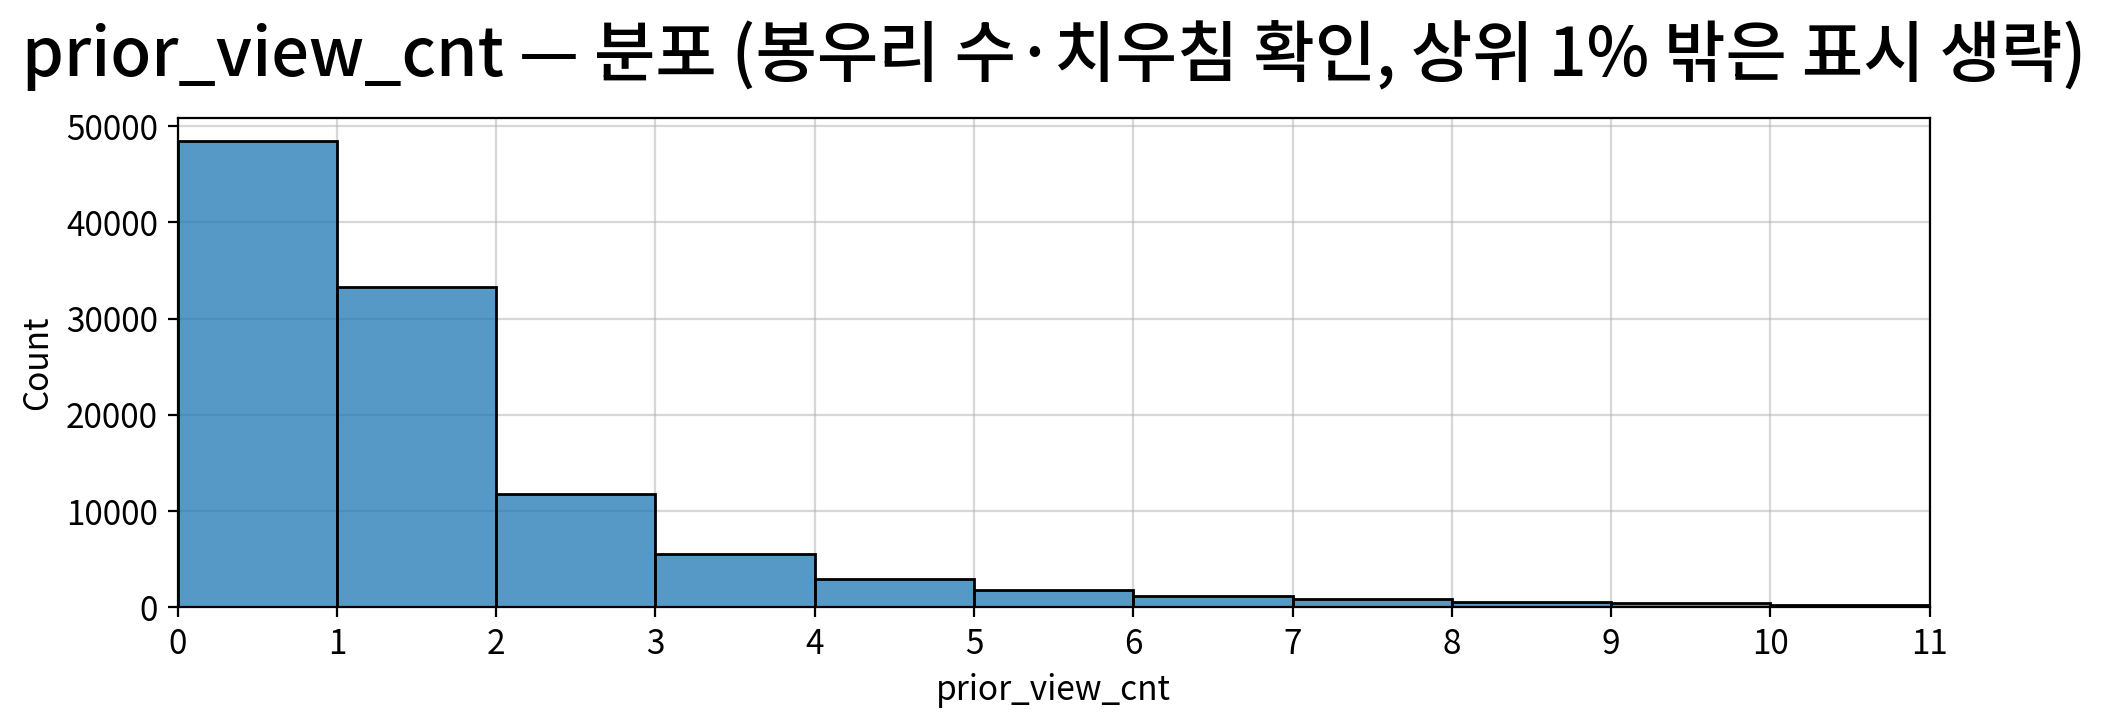

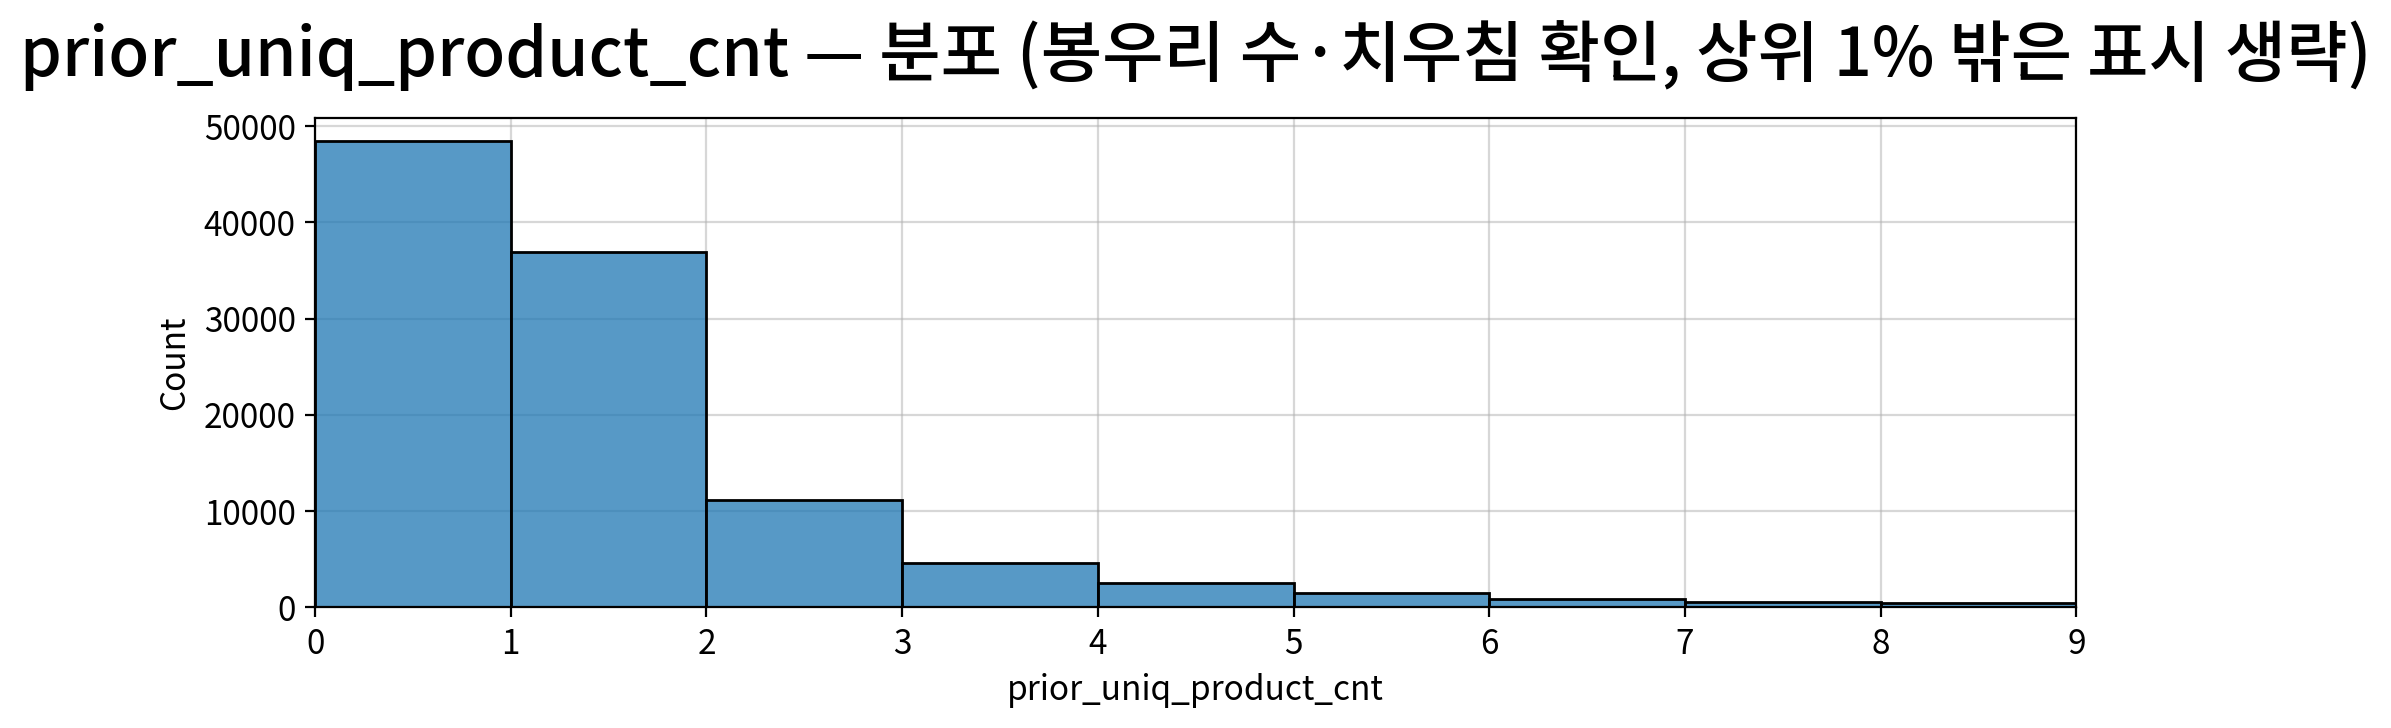

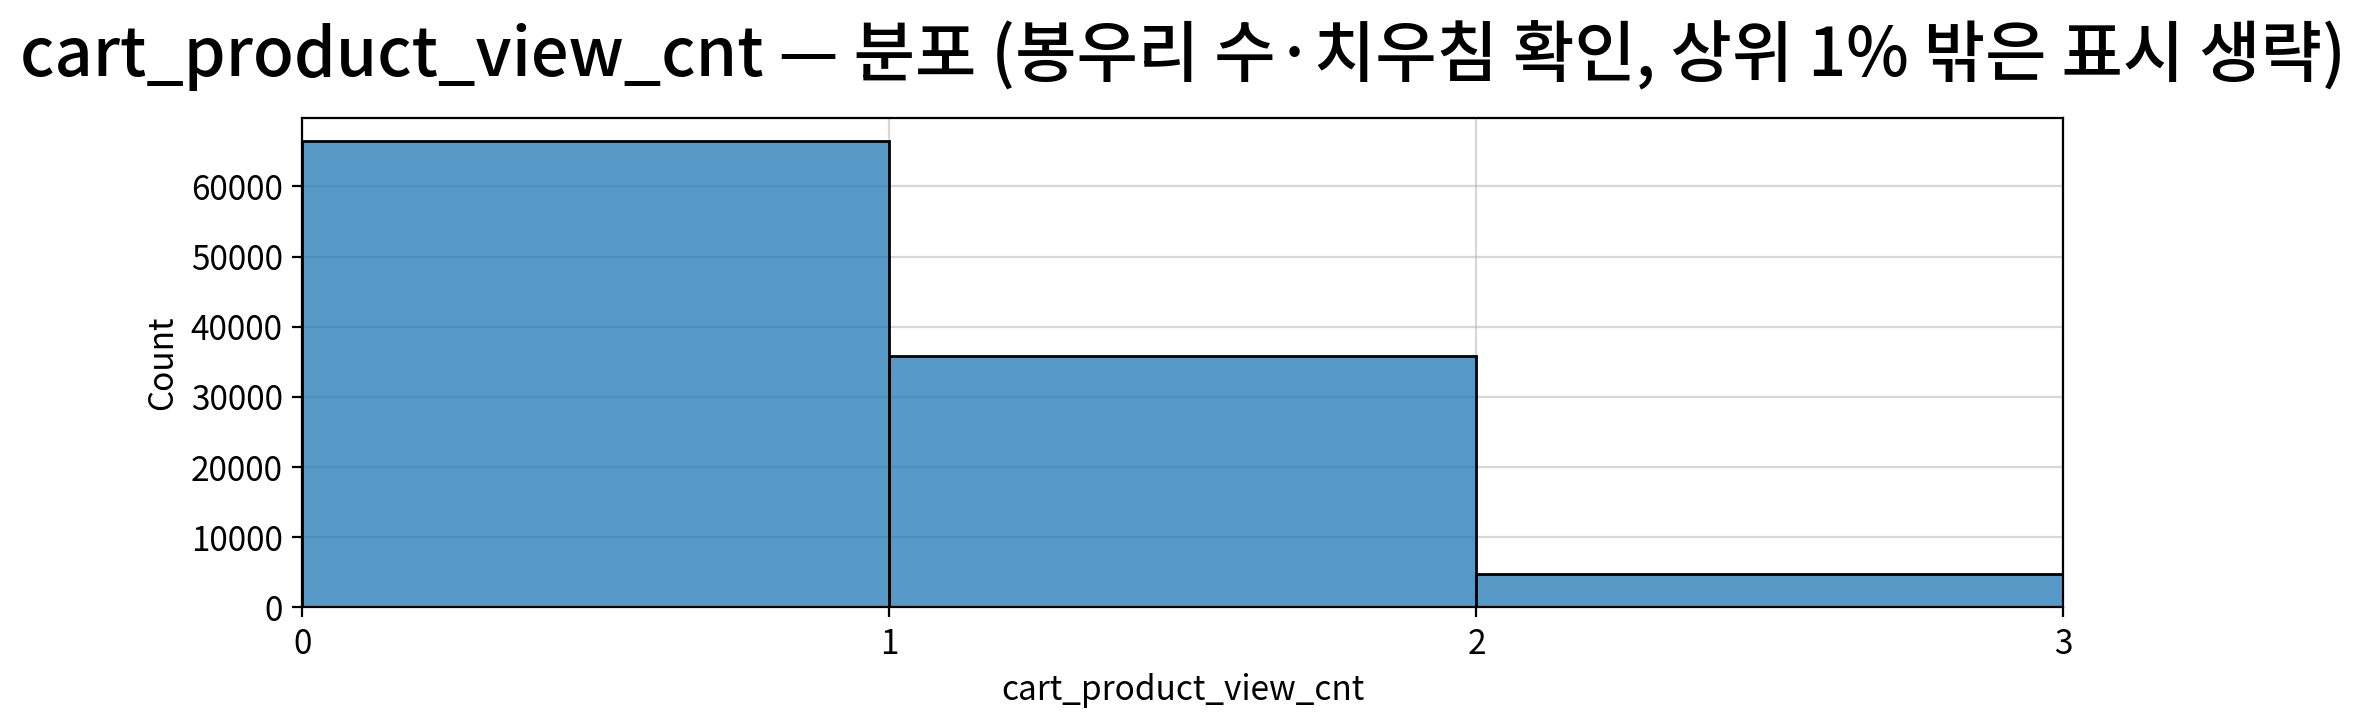

In [11]:
for c in A_NUM:
    # 상위 1%는 화면 표시만 생략한다 — 통계·이상치 판정에 쓰는 데이터는 그대로다 (#02 원칙 유지)
    upper = int(m[c].quantile(0.99))

    fig, ax = my_plot.init(width=1000, height=380,
                           title=f"{c} — 분포 (봉우리 수·치우침 확인, 상위 1% 밖은 표시 생략)")

    # kde=False : 이산 카운트에 KDE를 겹치면 정수마다 곡선이 출렁여 오히려 읽기 어렵다 (막대만으로 충분)
    # 정수 카운트라 1 단위로 구간을 나눠야 값별 빈도가 뭉개지지 않는다
    my_plot.histplot(data=m, x=c, kde=False, bins=range(0, upper + 2), ax=ax)

    ax.set_xlim(0, upper)
    ax.set_xticks(range(0, upper + 1))
    my_plot.show()

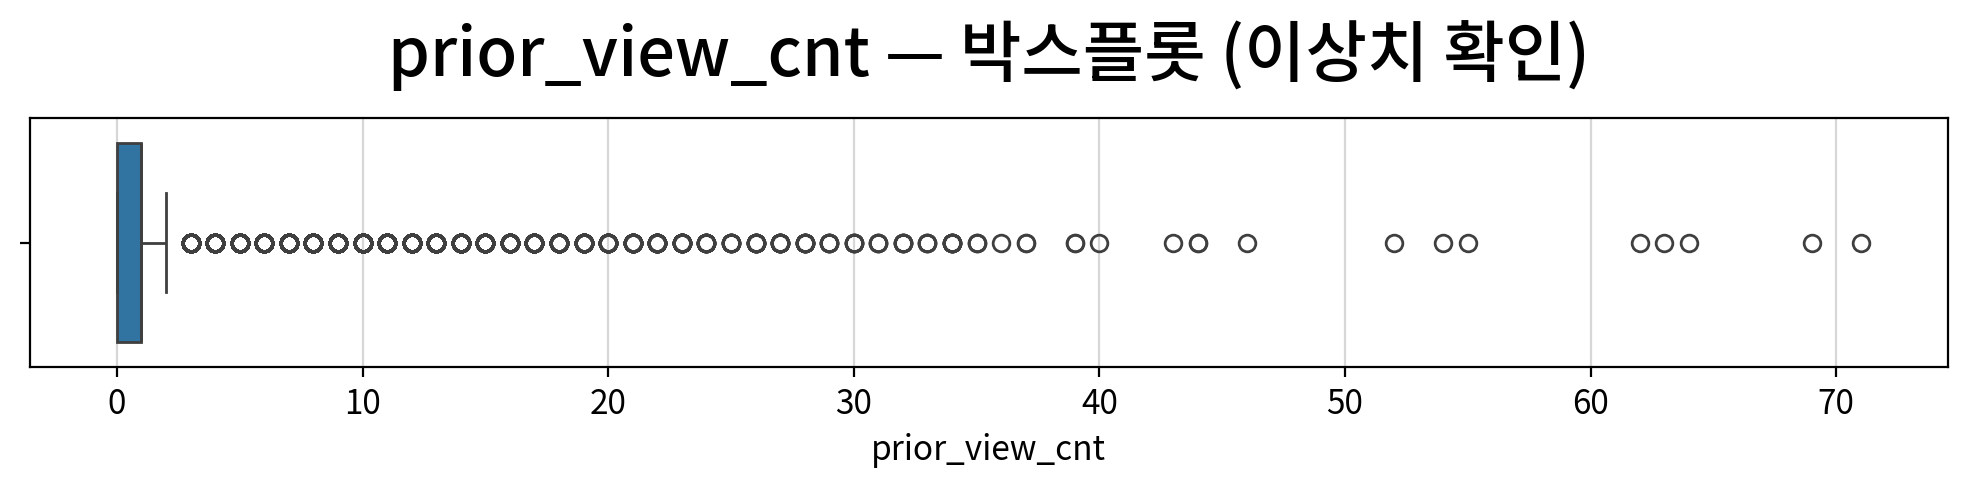

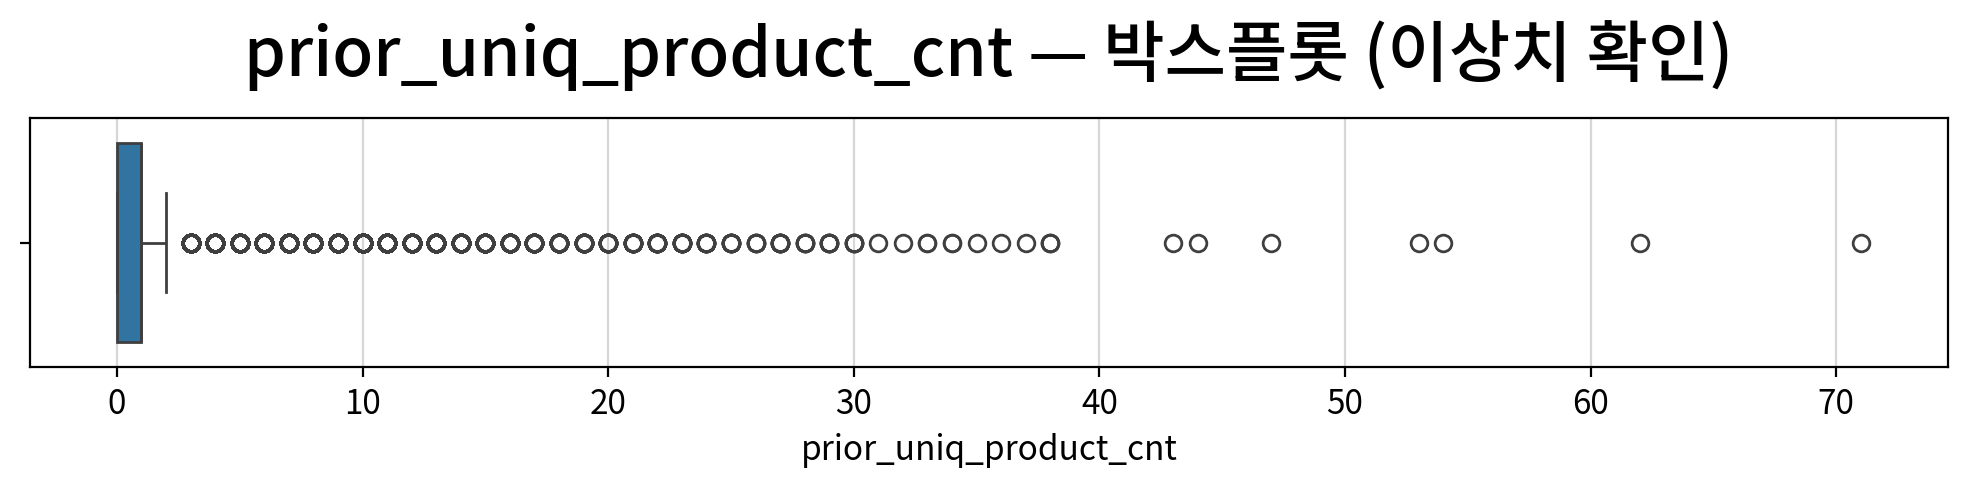

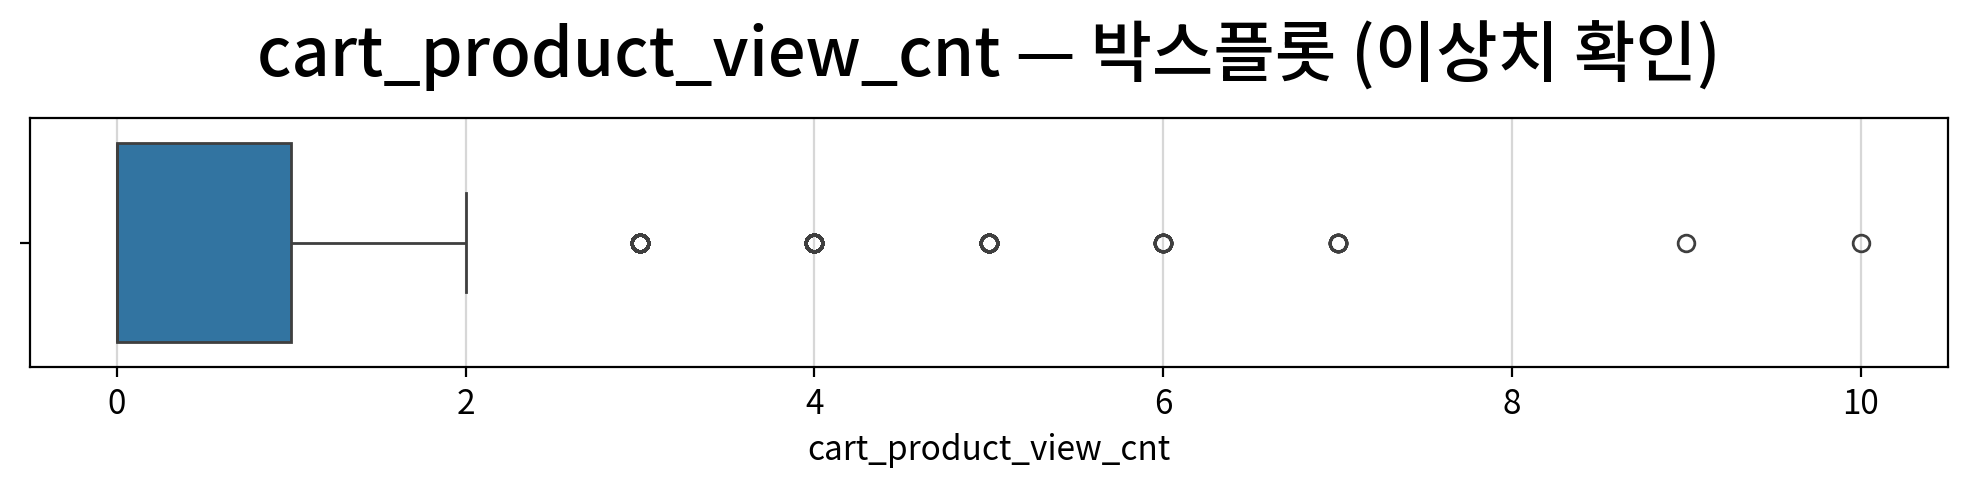

In [12]:
for c in A_NUM:
    my_plot.boxplot(data=m, x=c,
                    title=f"{c} — 박스플롯 (이상치 확인)",
                    width=1000, height=260)

## #06. 이진 변수 `has_prior_view`

이진 변수는 **분포 모양·왜도를 보지 않는다.** 두 값의 비율만 본다 `[LAB-08 §3-4]`.

`prior_view_cnt > 0`과 완전히 같은 변수이므로, 아래 `1`의 비율은
`#04`에서 구한 `prior_view_cnt`의 `0의 비율%`와 **정확히 100 − 그 값**이어야 한다. **검산이 된다.**

In [13]:
h = m[A_BIN].value_counts().sort_index().rename("고객 수").to_frame()
h["비율%"] = (h["고객 수"] / len(m) * 100).round(2)
h.index = ["0 (조회 없음)", "1 (조회 있음)"]

print("검산 : prior_view_cnt == 0 인 비율 =", f"{(m['prior_view_cnt'] == 0).mean() * 100:.2f}%")
print("       has_prior_view == 0 인 비율 =", f"{(m[A_BIN] == 0).mean() * 100:.2f}%")
print("       두 값이 같아야 한다.")
print()
h

검산 : prior_view_cnt == 0 인 비율 = 44.68%
       has_prior_view == 0 인 비율 = 44.68%
       두 값이 같아야 한다.



,고객 수,비율%
0 (조회 없음),48457,44.68
1 (조회 있음),60001,55.32


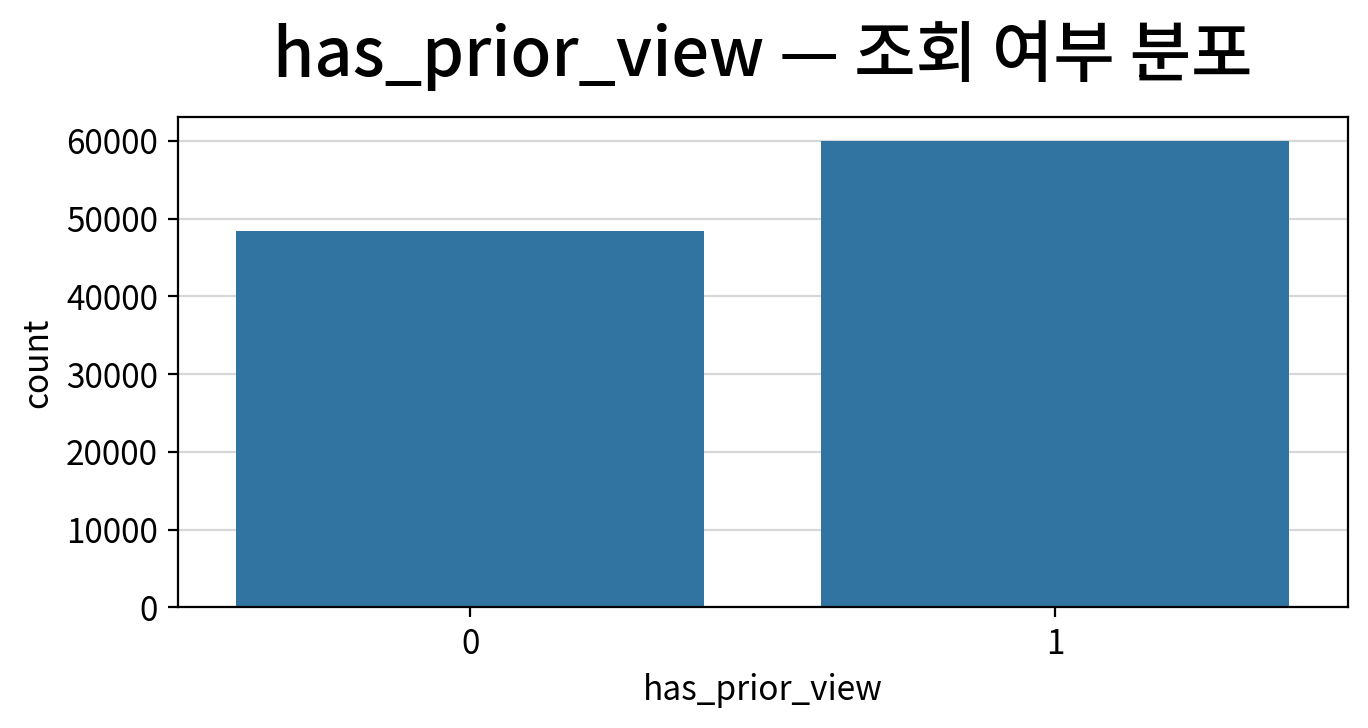

In [14]:
my_plot.countplot(data=m, x=A_BIN,
                  title="has_prior_view — 조회 여부 분포",
                  width=700, height=380)

## #07. A조 판정표

> **✏️ 수정 이력** — 관찰 내용은 이슬기 작성. 아래 세 곳만 Claude가 고쳤다(`#00` 수정 내역 참조).
> **① 봉우리 서술** 전 구간 근거로 교체 · **② 상관 0.969 출처 표기** · **③ 판단·조치 재작성**
> **관찰 내용 칸의 나머지 문장은 그대로 두었다.** ③은 두 분의 검토가 필요하다.

> **📐 수치 표기 규칙** — 판정문의 모든 수치에 **어느 셀에서 나오는지**를 `#04-2` 형태로 적는다.
> 외부 문서 인용은 출처를 밝힌다. 둘 다 아닌 수치는 쓰지 않는다.

각 변수마다 아래 4행을 채우고 마지막에 **`판단·조치` 한 줄**을 쓴다.

조치 표현은 교재가 실제로 쓴 어휘를 참고한다 
`로그 변환 + 이상치 처리` / `변환 불필요, 다봉만 유의` / `그대로 사용 가능` / `로그 변환 고려` /
`사실상 범주형 → 선형 가정 주의`

---

### `prior_view_cnt`

| 점검 항목 | 관찰 내용 |
|---|---|
| 분포 모양(왜도) | 왜도 5.90으로 매우 큼. 평균(1.28)이 중앙값(1.0)보다 커서 뚜렷한 **오른쪽 치우침(우측 꼬리)** |
| 봉우리 수 | 0(44.68%)에서 최고점, **상위 5개 값(0~4)에서 단조 감소** → **단봉**. 다만 전 구간을 세면 꼬리 쪽에 **역전 6회(최대 +5명)**가 있다 — 규모가 작아 노이즈로 본다 (`#04-2-1`) |
| 이상치 | IQR 상한(2.5회) 초과 **14,961명(13.79%)**, 전부 상단 이상치(하단 0명). 큰 값은 오류가 아니라 실제로 많이 조회한 고객 |
| 이산점(군집) | 고유값은 51종이지만 **상위 5개 값(0~4회)이 94.06%**를 차지 — 사실상 0~4에 몰린 이산 변수 |

**판단·조치** : **로그 변환 대상(`log1p`) · 연속형 유지 · 이산성은 기록만**

- **변환** — 왜도 5.901 → `log1p` 후 **1.042**(`#04-1-1`). 설계 §3-4의 *"개선되지 않으면 변환하지 않는다"*는
  통과하므로 변환 대상으로 둔다. **단, 변환 후에도 우리 기준 1.0을 넘는다** → `#09` 미결 ①.
- **이산성** — 상위 5개 값이 94.06%를 덮지만(`#04-2`) **기록만 한다.**
  `log1p`는 단조변환이라 고유값이 **51종 → 51종**으로 그대로여서(`#04-1-1`) 로그변환으로 해소되지 않고,
  구간화는 설계 §3-10이 **하지 않기로 정한 처리**다. 로짓 선형성은 ⑤의 Box-Tidwell로 확인한다.

---

### `prior_uniq_product_cnt`

| 점검 항목 | 관찰 내용 |
|---|---|
| 분포 모양(왜도) | 왜도 6.04로 셋 중 가장 큼. 평균(1.12) > 중앙값(1.0) → **오른쪽 치우침(우측 꼬리)** |
| 봉우리 수 | 0(44.68%)에서 최고점, **상위 5개 값(0~4)에서 단조 감소** → **단봉**. 전 구간에서는 **역전 4회(최대 +4명)** — 노이즈 규모다 (`#04-2-1`). `prior_view_cnt`와 사실상 같은 모양 (**상관 0.969 — 출처 : 브리핑 §8-①, 이 노트북의 출력이 아니다**) |
| 이상치 | IQR 상한(2.5회) 초과 **11,947명(11.02%)**, 전부 상단 이상치 |
| 이산점(군집) | 고유값 46종 중 **상위 5개 값(0~4종)이 95.60%**를 차지 — `prior_view_cnt`보다도 더 소수 값에 몰림 |

**판단·조치** : **로그 변환 대상(`log1p`) · 연속형 유지 · 이산성은 기록만**

- **변환** — 왜도 6.044 → `log1p` 후 **1.033**(`#04-1-1`). `prior_view_cnt`와 같은 상황이다.
  **변환 후에도 기준 1.0을 넘는다** → `#09` 미결 ①.
- **이산성** — 상위 5개 값 95.60%(`#04-2`), 고유값 **46종 → 46종**(`#04-1-1`). 위와 같은 이유로 **기록만 한다.**
- **중복** — `prior_view_cnt`와 어느 쪽을 남길지는 **여기서 정하지 않는다.** `10`번 다변량(VIF)의 일이다.

---

### `cart_product_view_cnt`

| 점검 항목 | 관찰 내용 |
|---|---|
| 분포 모양(왜도) | 왜도 1.75로 셋 중 가장 작지만 여전히 기준(1.0) 이상. 중앙값이 0이라 절반 이상이 0회 |
| 봉우리 수 | 0(61.30%)에서 최고점, 이후 감소 → **단봉**. **전 구간 단조감소(역전 0회)**로 확인됨 — 셋 중 유일하다 (`#04-2-1`) |
| 이상치 | IQR 상한(2.5회) 초과 **1,234명(1.14%)** — 셋 중 이상치 비율이 가장 낮음 |
| 이산점(군집) | 고유값이 **10종뿐**이고 **상위 5개 값(0~4회)이 99.92%**를 덮음 — 사실상 0/1/2 몇 개 값에 극도로 몰린 이산 변수 |

**판단·조치** : **로그 변환 대상(`log1p`) · 연속형 유지 · 이산성은 기록만**

- **변환** — 왜도 1.751 → `log1p` 후 **0.809**(`#04-1-1`). **셋 중 유일하게 기준 1.0 아래로 내려간다.**
- **이산성** — 고유값 **10종**, 0이 61.30%, 상위 5개 값이 99.92%(`#04-2`) — **셋 중 가장 이산적**이다.
  변환 후에도 **10종 그대로**(`#04-1-1`). 그럼에도 범주형으로 바꾸지 않는다 — 설계 §3-10이
  연속형의 구간화를 하지 않기로 정했고, 그 기준이 교재에 없기 때문이다. **기록만 한다.**

---

### `has_prior_view`

| 점검 항목 | 관찰 내용 |
|---|---|
| 범주 수 | 2 (0 / 1) |
| 최빈 범주(비율) | 1 · 조회 있음 — 60,001명 (55.32%) |
| 최소 범주(비율) | 0 · 조회 없음 — 48,457명 (44.68%) |
| 균형 여부 | 두 범주 모두 40% 이상으로 **균형** (극단적 불균형 아님) |

**판단·조치** : 그대로 사용 가능 (두 범주 비율이 55.3% : 44.7%로 균형, 검정력 문제 없음)


## #08. A조 요약표 — 배지환에게 전달할 것

아래 셀이 **자동으로 채워지는 부분**을 만든다.
`판단·조치` 칸은 `#07`에서 쓴 문장을 손으로 옮긴다 (오타로 값이 틀어지는 것을 막기 위해 수치는 코드가 만든다).

In [15]:
A_RESULT = view[["mean", "50%", "max", "skew", "0의 비율%", "이상치%", "고유값 수", "로그변환 후보"]].copy()
A_RESULT.insert(0, "담당", "A · 이슬기")
A_RESULT.insert(1, "척도", "연속")

# 이진 변수는 위 표에 들어가지 않으므로 따로 한 줄 만든다
A_RESULT.loc[A_BIN] = ["A · 이슬기", "이진",
                       m[A_BIN].mean(), m[A_BIN].median(), m[A_BIN].max(),
                       None, round((m[A_BIN] == 0).mean() * 100, 2), None,
                       m[A_BIN].nunique(), False]

# 판단·조치는 사람이 적는다 (#07 에서 옮겨 적을 것)
# #07 판정표의 결론을 한 줄로 압축한 것.
# dict 로 두면 키가 하나라도 빠졌을 때 KeyError 로 즉시 터진다 —
# 빈 칸인 채로 CSV 가 저장되는 사고를 막는다.
VERDICT = {
    "prior_view_cnt":
        "로그변환 대상(log1p, 5.901→1.042) · 변환 후에도 기준 1.0 초과 → 미결 ① · "
        "연속형 유지 · 이산성(상위5개 94.06%)은 기록만, 고유값 51종→51종이라 변환으로 해소 안 됨",
    "prior_uniq_product_cnt":
        "로그변환 대상(log1p, 6.044→1.033) · 변환 후에도 기준 1.0 초과 → 미결 ① · "
        "연속형 유지 · 이산성(상위5개 95.60%)은 기록만 · prior_view_cnt 와의 택일은 10번 VIF",
    "cart_product_view_cnt":
        "로그변환 대상(log1p, 1.751→0.809, 셋 중 유일하게 기준 통과) · "
        "연속형 유지 · 고유값 10종으로 셋 중 가장 이산적이나 구간화하지 않음(설계 §3-10)",
    "has_prior_view":
        "그대로 사용 가능 · 55.32% : 44.68% 로 균형 · 검정력 문제 없음",
}

A_RESULT["판단·조치"] = [VERDICT[i] for i in A_RESULT.index]

A_RESULT.round(3).T

,prior_view_cnt,prior_uniq_product_cnt,cart_product_view_cnt,has_prior_view
담당,A · 이슬기,A · 이슬기,A · 이슬기,A · 이슬기
척도,연속,연속,연속,이진
mean,1.28,1.12,0.458,0.553
50%,1.0,1.0,0.0,1.0
max,71.0,71.0,10.0,1.0
skew,5.901359,6.043646,1.751322,None
0의 비율%,44.68,44.68,61.3,44.68
이상치%,13.79,11.02,1.14,None
고유값 수,51,46,10,2
로그변환 후보,True,True,True,False


In [16]:
# 배지환에게 전달할 파일로 저장한다.
# 두 사람이 같은 .ipynb 를 동시에 열면 저장이 서로를 덮어쓰므로, 출력만 파일로 주고받는다.
A_PATH = OUT + r"\09a_단변량_A조.csv"
A_RESULT.to_csv(A_PATH, encoding="utf-8-sig")
print("저장 완료 :", A_PATH)

저장 완료 : .\output\09a_단변량_A조.csv


## #09. 다음

| 할 일 | 누가 |
|---|---|
| `#07` 판정표 4개를 문장으로 채운다 | 이슬기 |
| `09a_단변량_A조.csv` 전달 | 이슬기 → 배지환 |
| **A조 결과를 함께 읽는다** | **둘이 함께** — 조회 변수가 이 프로젝트의 핵심 질문이다 |
| B조 결과 검수 | 이슬기 |

### 미결 ① — `log1p` 후에도 기준 1.0을 넘는 두 변수 〈둘이 함께 정한다〉

`prior_view_cnt`(→ 1.042)와 `prior_uniq_product_cnt`(→ 1.033)는 **변환 후에도 우리 기준을 넘는다**(`#04-1-1`).

**설계 §3-4는 이 경우를 다루지 않았다.** 정할 것은 하나다 — *변환한 채로 갈 것인가.*

| 갈래 | 근거 | 대가 |
|---|---|---|
| **(가) 변환한다** | 5.9 → 1.04는 명백한 개선이고, 설계의 조건(*"개선되지 않으면 하지 않는다"*)은 통과한다. 기준 1.0 자체가 「교재 미기재」로 우리가 정한 선이라 절대적이지 않다 | 변환 후에도 기준 미달인 상태로 모형에 들어간다 |
| **(나) 변환하지 않는다** | 기준을 넘지 못했으므로 통과 실패로 본다 | 왜도 5.9를 그대로 투입하게 된다 |

> **구간화(명목형 전환)는 선택지에 없다.** 설계 §3-10이 *연속형의 구간화를 하지 않는다*고 정했고,
> 그 이유(구간 기준이 교재에 없다)가 여기에도 그대로 적용된다.

어느 쪽이든 **사유를 문장으로 남기고**, 설계 `§6 조정 기록`에 적는다.

---

> **아직 하지 않은 것** — Y와의 관계(이변량), 셋 중 무엇을 남길지(다변량 VIF).
> 둘 다 `10`번의 일이다. 여기서 앞질러 보지 않는다.